# 🔧 02 — Feature Engineering
**Goal:** Transform raw columns into model-ready features using insights from EDA.

## Plan
| Step | Action |
|------|--------|
| 1 | Load & clean raw data |
| 2 | Engineer interaction & ratio features |
| 3 | Ordinal encoding (Year, Skill, Use Case) |
| 4 | One-Hot encoding (Major, Policy) |
| 5 | Scale numericals |
| 6 | Mutual information — feature importance preview |
| 7 | Build & validate full sklearn pipeline |
| 8 | Save processed datasets |


## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                      "axes.spines.right": False})

FIGURES = Path("../reports/figures")
PROCESSED = Path("../Data/processed")
FIGURES.mkdir(parents=True, exist_ok=True)
PROCESSED.mkdir(parents=True, exist_ok=True)

def save(name):
    plt.savefig(FIGURES / name, bbox_inches="tight", dpi=150)
    plt.show()

print("Setup complete ✓")

Setup complete ✓


## 2. Load & Clean Raw Data

In [2]:
RAW = Path("../Data/raw/ai_student_impact_dataset (1).csv")
df = pd.read_csv(RAW)
df = df.drop(columns=["Student_ID"])

# Bool → int
df["Paid_Subscription"] = df["Paid_Subscription"].map(
    {True: 1, False: 0, "True": 1, "False": 0}
).astype(int)

print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head(3)

Shape: (50000, 15)
Missing values: 0


,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,1,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,Medical,Junior,3.821,1.12,Ideation,Advanced,5,0,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,0,10.35,5,Strict_Ban,9,3.499,73.93,Medium


## 3. Feature Engineering

### 3.1 Interaction & Ratio Features
Derived from EDA insights:
- `study_ratio` — captures the substitution effect between traditional and AI study
- `total_study_hours` — total cognitive load
- `genai_dependency_score` — amplifies usage by dependency (key burnout signal)
- `ai_efficiency` — how much skill retention per GenAI hour
- `anxiety_gpa_pressure` — interaction between exam anxiety and academic standing

In [3]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Ratio / interaction
    df["study_ratio"]            = df["Traditional_Study_Hours"] / (df["Weekly_GenAI_Hours"] + 1)
    df["total_study_hours"]      = df["Traditional_Study_Hours"] + df["Weekly_GenAI_Hours"]
    df["genai_dependency_score"] = df["Weekly_GenAI_Hours"] * df["Perceived_AI_Dependency"]
    df["ai_efficiency"]          = df["Skill_Retention_Score"] / (df["Weekly_GenAI_Hours"] + 1)
    df["anxiety_gpa_pressure"]   = df["Anxiety_Level_During_Exams"] * (4 - df["Pre_Semester_GPA"])

    return df

df = engineer_features(df)

new_cols = ["study_ratio","total_study_hours","genai_dependency_score",
            "ai_efficiency","anxiety_gpa_pressure"]
print("New features created:")
df[new_cols].describe().round(3)

New features created:


,study_ratio,total_study_hours,genai_dependency_score,ai_efficiency,anxiety_gpa_pressure
count,50000.000,50000.000,50000.000,50000.000,50000.000
mean,2.626,19.637,39.562,17.060,3.647
std,2.969,9.031,59.898,16.159,2.932
min,0.024,1.010,0.000,0.263,0.006
25%,0.709,13.410,5.078,5.939,1.425
50%,1.554,18.260,16.590,11.196,2.895
75%,3.362,24.280,46.485,22.272,5.076
max,32.899,64.150,400.000,100.000,25.080


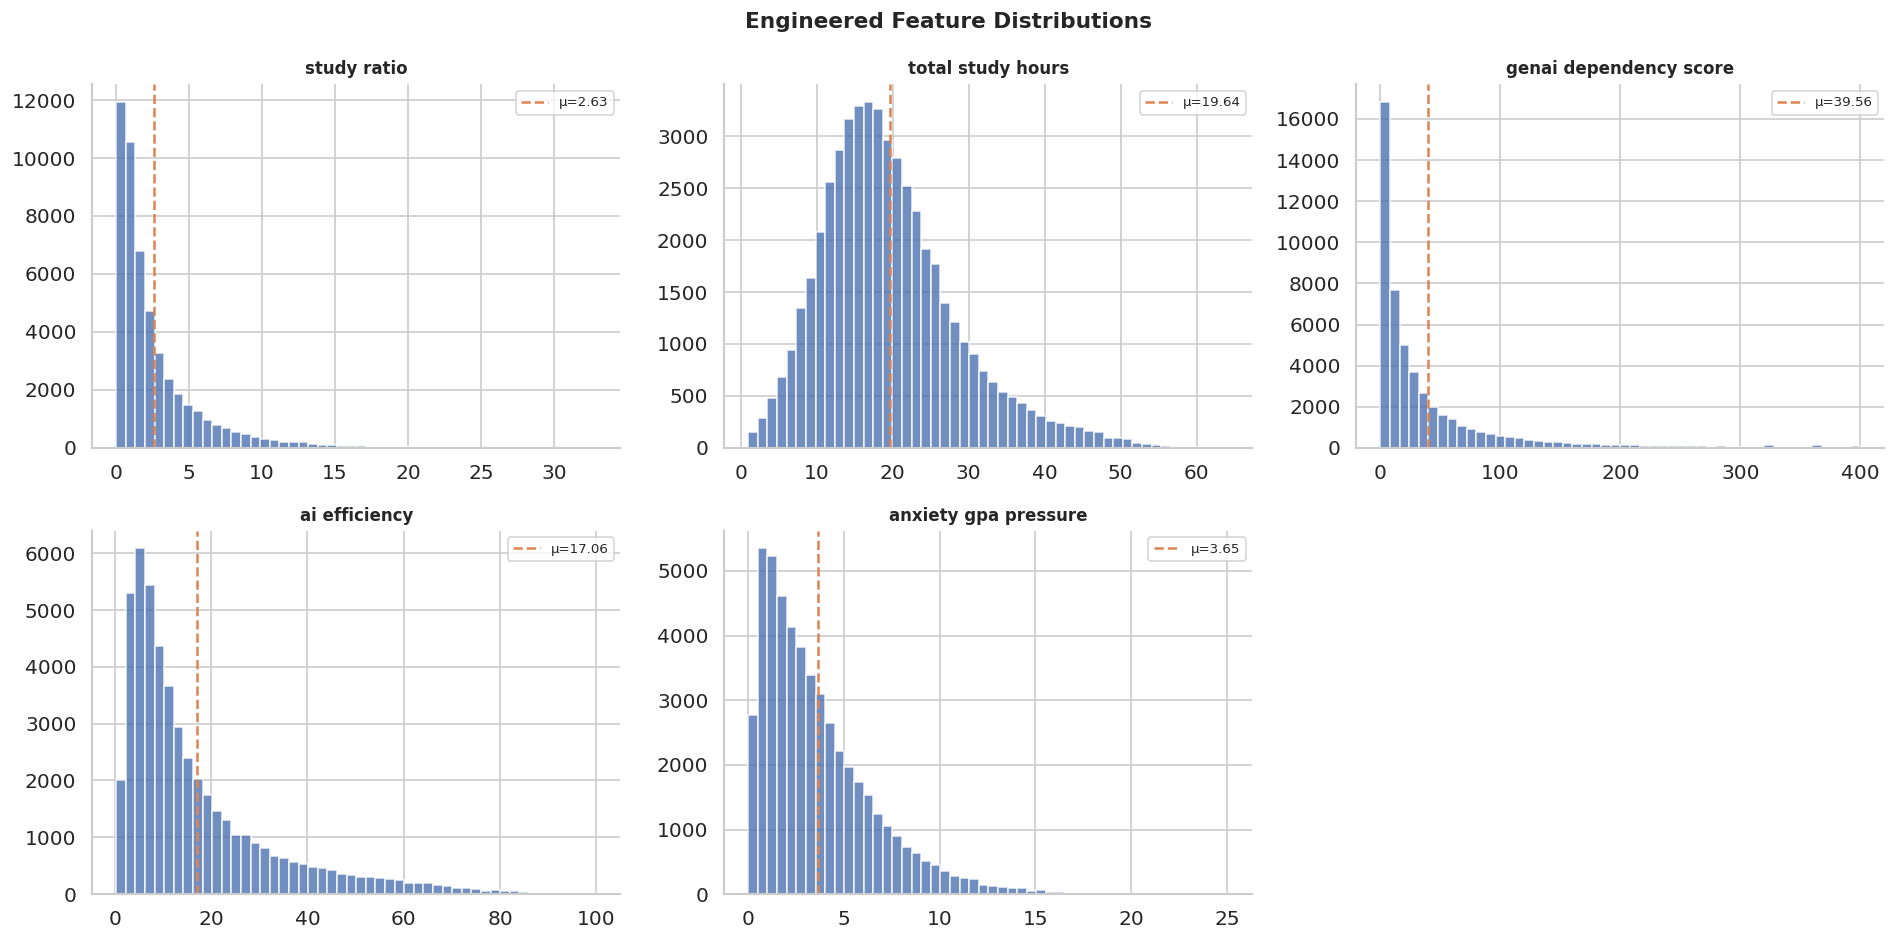

In [4]:
# Visualise new features
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, new_cols):
    ax.hist(df[col], bins=50, color="#4C72B0", edgecolor="white", alpha=0.8)
    ax.axvline(df[col].mean(), color="#DD8452", linestyle="--", lw=1.5, label=f"μ={df[col].mean():.2f}")
    ax.set_title(col.replace("_", " "), fontweight="bold", fontsize=10)
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle("Engineered Feature Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
save("11_engineered_features.png")

### 3.2 Correlations of New Features with Targets

In [5]:
targets = ["Post_Semester_GPA", "Burnout_Risk_Level"]
burnout_map = {"Low": 0, "Medium": 1, "High": 2}
df["_burnout_num"] = df["Burnout_Risk_Level"].map(burnout_map)

print("Correlations of engineered features with Post_Semester_GPA:")
gpa_corr = df[new_cols + ["Post_Semester_GPA"]].corr()["Post_Semester_GPA"].drop("Post_Semester_GPA")
print(gpa_corr.sort_values(key=abs, ascending=False).round(4))
print()

print("Correlations of engineered features with Burnout (0=Low,1=Med,2=High):")
burnout_corr = df[new_cols + ["_burnout_num"]].corr()["_burnout_num"].drop("_burnout_num")
print(burnout_corr.sort_values(key=abs, ascending=False).round(4))

df = df.drop(columns=["_burnout_num"])

Correlations of engineered features with Post_Semester_GPA:
anxiety_gpa_pressure     -0.6562
total_study_hours         0.0616
study_ratio               0.0439
genai_dependency_score   -0.0276
ai_efficiency             0.0147
Name: Post_Semester_GPA, dtype: float64

Correlations of engineered features with Burnout (0=Low,1=Med,2=High):
genai_dependency_score    0.4339
total_study_hours         0.3524
ai_efficiency            -0.3164
study_ratio              -0.2982
anxiety_gpa_pressure      0.1679
Name: _burnout_num, dtype: float64


## 4. Ordinal Encoding
Three columns have a **meaningful order** — we preserve it with integer mapping instead of one-hot encoding.

In [6]:
# Year of Study: clear academic progression
YEAR_ORDER = {"Freshman":1, "Sophomore":2, "Junior":3, "Senior":4, "Graduate":5}

# Prompt Engineering Skill: clear skill ladder
SKILL_ORDER = {"Beginner":1, "Intermediate":2, "Advanced":3}

# Primary Use Case: ordered by avg Post-GPA from EDA (passive → active AI use)
USE_CASE_RANK = {
    "Direct_Answer_Generation": 1,
    "Copywriting/Drafting":     2,
    "Ideation":                 3,
    "Summarizing_Reading":      4,
    "Debugging/Troubleshooting":5,
}

df["Year_of_Study_enc"]             = df["Year_of_Study"].map(YEAR_ORDER)
df["Prompt_Engineering_Skill_enc"]  = df["Prompt_Engineering_Skill"].map(SKILL_ORDER)
df["Primary_Use_Case_enc"]          = df["Primary_Use_Case"].map(USE_CASE_RANK)

print("Ordinal encoding applied:")
for orig, enc in [("Year_of_Study","Year_of_Study_enc"),
                  ("Prompt_Engineering_Skill","Prompt_Engineering_Skill_enc"),
                  ("Primary_Use_Case","Primary_Use_Case_enc")]:
    sample = df[[orig, enc]].drop_duplicates().sort_values(enc)
    print(f"\n{orig}:")
    print(sample.to_string(index=False))

Ordinal encoding applied:

Year_of_Study:
Year_of_Study  Year_of_Study_enc
     Freshman                  1
    Sophomore                  2
       Junior                  3
       Senior                  4
     Graduate                  5

Prompt_Engineering_Skill:
Prompt_Engineering_Skill  Prompt_Engineering_Skill_enc
                Beginner                             1
            Intermediate                             2
                Advanced                             3

Primary_Use_Case:
         Primary_Use_Case  Primary_Use_Case_enc
 Direct_Answer_Generation                     1
     Copywriting/Drafting                     2
                 Ideation                     3
      Summarizing_Reading                     4
Debugging/Troubleshooting                     5


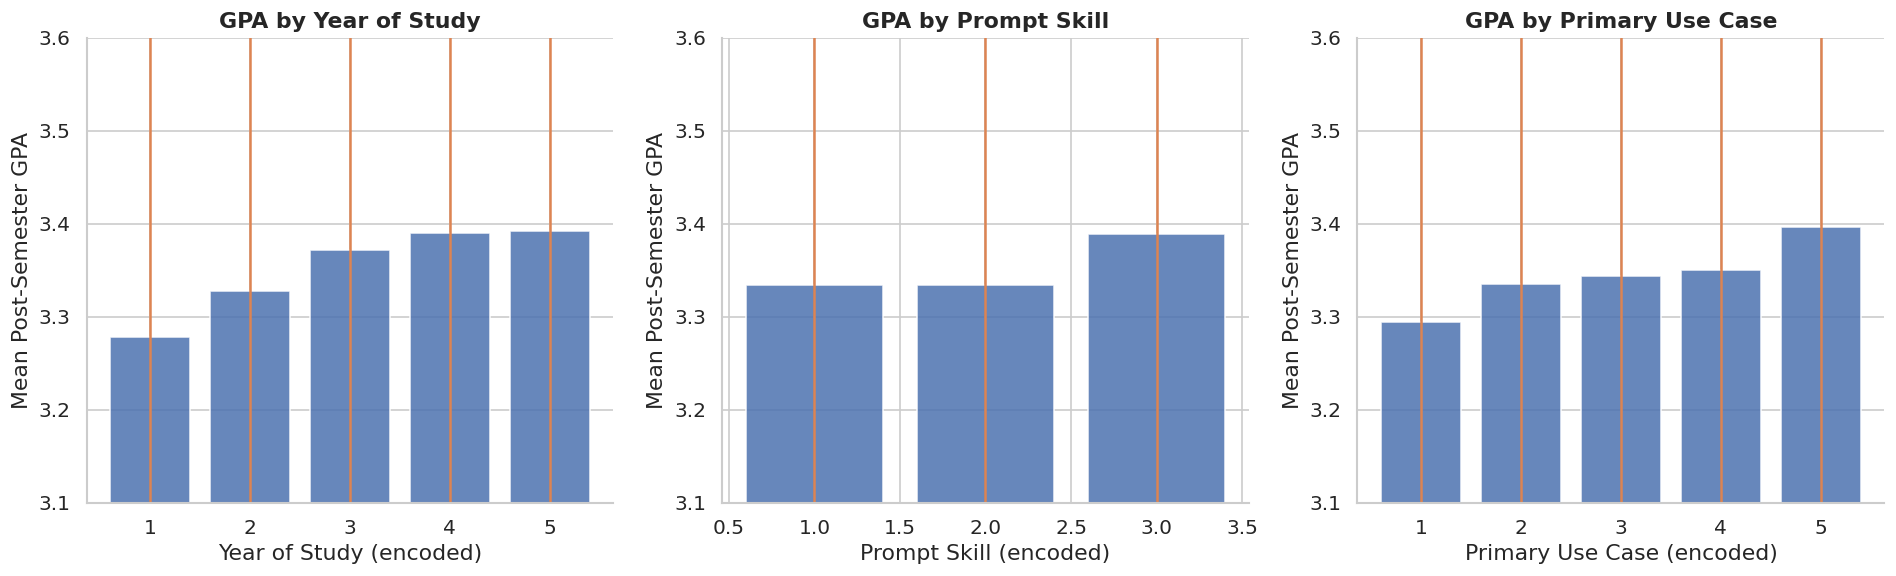

In [7]:
# Visualise ordinal features vs Post-Semester GPA
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (enc, label) in zip(axes, [
    ("Year_of_Study_enc",            "Year of Study"),
    ("Prompt_Engineering_Skill_enc", "Prompt Skill"),
    ("Primary_Use_Case_enc",         "Primary Use Case"),
]):
    means = df.groupby(enc)["Post_Semester_GPA"].mean()
    stds  = df.groupby(enc)["Post_Semester_GPA"].std()
    ax.bar(means.index, means.values, yerr=stds.values,
           color="#4C72B0", edgecolor="white", alpha=0.85,
           error_kw=dict(ecolor="#DD8452", capsize=5, lw=1.5))
    ax.set_xlabel(f"{label} (encoded)")
    ax.set_ylabel("Mean Post-Semester GPA")
    ax.set_title(f"GPA by {label}", fontweight="bold")
    ax.set_ylim(3.1, 3.6)

plt.tight_layout()
save("12_ordinal_vs_gpa.png")

## 5. One-Hot Encoding
`Major_Category` and `Institutional_Policy` have **no natural order** → one-hot encode.  
Original ordinal string columns are dropped after encoding.

In [8]:
ohe_cols = ["Major_Category", "Institutional_Policy"]
df_ohe = pd.get_dummies(df, columns=ohe_cols, drop_first=False, dtype=int)

# Drop original string columns that were ordinally encoded
drop_originals = ["Year_of_Study", "Prompt_Engineering_Skill", "Primary_Use_Case"]
df_ohe = df_ohe.drop(columns=drop_originals)

print(f"Shape after OHE: {df_ohe.shape}")
print("\nNew OHE columns:")
new_ohe = [c for c in df_ohe.columns if any(base in c for base in ohe_cols)]
print(new_ohe)

Shape after OHE: (50000, 26)

New OHE columns:
['Major_Category_Arts', 'Major_Category_Business', 'Major_Category_Humanities', 'Major_Category_Medical', 'Major_Category_STEM', 'Institutional_Policy_Actively_Encouraged', 'Institutional_Policy_Allowed_With_Citation', 'Institutional_Policy_Strict_Ban']


## 6. Final Feature Set

In [9]:
TARGET_REG   = "Post_Semester_GPA"
TARGET_CLF   = "Burnout_Risk_Level"

# For REGRESSION: drop both targets + Burnout (would be leakage)
# gpa_delta would also be leakage since it uses Post_Semester_GPA
feature_cols = [c for c in df_ohe.columns
                if c not in [TARGET_REG, TARGET_CLF]]

print(f"Total features: {len(feature_cols)}")
print("\nFeature list:")
for i, f in enumerate(feature_cols, 1):
    print(f"  {i:>2}. {f}")

Total features: 24

Feature list:
   1. Pre_Semester_GPA
   2. Weekly_GenAI_Hours
   3. Tool_Diversity
   4. Paid_Subscription
   5. Traditional_Study_Hours
   6. Perceived_AI_Dependency
   7. Anxiety_Level_During_Exams
   8. Skill_Retention_Score
   9. study_ratio
  10. total_study_hours
  11. genai_dependency_score
  12. ai_efficiency
  13. anxiety_gpa_pressure
  14. Year_of_Study_enc
  15. Prompt_Engineering_Skill_enc
  16. Primary_Use_Case_enc
  17. Major_Category_Arts
  18. Major_Category_Business
  19. Major_Category_Humanities
  20. Major_Category_Medical
  21. Major_Category_STEM
  22. Institutional_Policy_Actively_Encouraged
  23. Institutional_Policy_Allowed_With_Citation
  24. Institutional_Policy_Strict_Ban


In [10]:
# Summary: feature types
num_feats = [c for c in feature_cols if df_ohe[c].dtype in ["float64","float32"]]
int_feats = [c for c in feature_cols if df_ohe[c].dtype in ["int64","int32","int8","uint8"]]

print(f"Float features  ({len(num_feats)}): {num_feats}")
print(f"Integer features({len(int_feats)}): {int_feats}")

Float features  (9): ['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Traditional_Study_Hours', 'Skill_Retention_Score', 'study_ratio', 'total_study_hours', 'genai_dependency_score', 'ai_efficiency', 'anxiety_gpa_pressure']
Integer features(15): ['Tool_Diversity', 'Paid_Subscription', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams', 'Year_of_Study_enc', 'Prompt_Engineering_Skill_enc', 'Primary_Use_Case_enc', 'Major_Category_Arts', 'Major_Category_Business', 'Major_Category_Humanities', 'Major_Category_Medical', 'Major_Category_STEM', 'Institutional_Policy_Actively_Encouraged', 'Institutional_Policy_Allowed_With_Citation', 'Institutional_Policy_Strict_Ban']


## 7. Mutual Information — Feature Importance Preview
Mutual information is model-agnostic and captures non-linear relationships.

In [11]:
X = df_ohe[feature_cols].copy()

# ── Regression MI ─────────────────────────────────────────────────────────
y_reg = df_ohe[TARGET_REG]
mi_reg = mutual_info_regression(X, y_reg, random_state=42)
mi_reg_s = pd.Series(mi_reg, index=feature_cols).sort_values(ascending=False)

# ── Classification MI ─────────────────────────────────────────────────────
y_clf = df_ohe[TARGET_CLF]
mi_clf = mutual_info_classif(X, y_clf, random_state=42)
mi_clf_s = pd.Series(mi_clf, index=feature_cols).sort_values(ascending=False)

print("Top 15 features by MI — Regression (Post_Semester_GPA):")
print(mi_reg_s.head(15).round(4).to_string())
print()
print("Top 15 features by MI — Classification (Burnout_Risk_Level):")
print(mi_clf_s.head(15).round(4).to_string())

Top 15 features by MI — Regression (Post_Semester_GPA):
Pre_Semester_GPA                            0.9378
anxiety_gpa_pressure                        0.3703
Skill_Retention_Score                       0.0160
Traditional_Study_Hours                     0.0111
total_study_hours                           0.0105
ai_efficiency                               0.0061
Major_Category_Medical                      0.0056
Tool_Diversity                              0.0054
Perceived_AI_Dependency                     0.0047
Major_Category_Business                     0.0042
Prompt_Engineering_Skill_enc                0.0030
Institutional_Policy_Actively_Encouraged    0.0012
Weekly_GenAI_Hours                          0.0011
study_ratio                                 0.0002
Major_Category_Humanities                   0.0001

Top 15 features by MI — Classification (Burnout_Risk_Level):
genai_dependency_score        0.1325
Weekly_GenAI_Hours            0.1301
ai_efficiency                 0.1245
study_

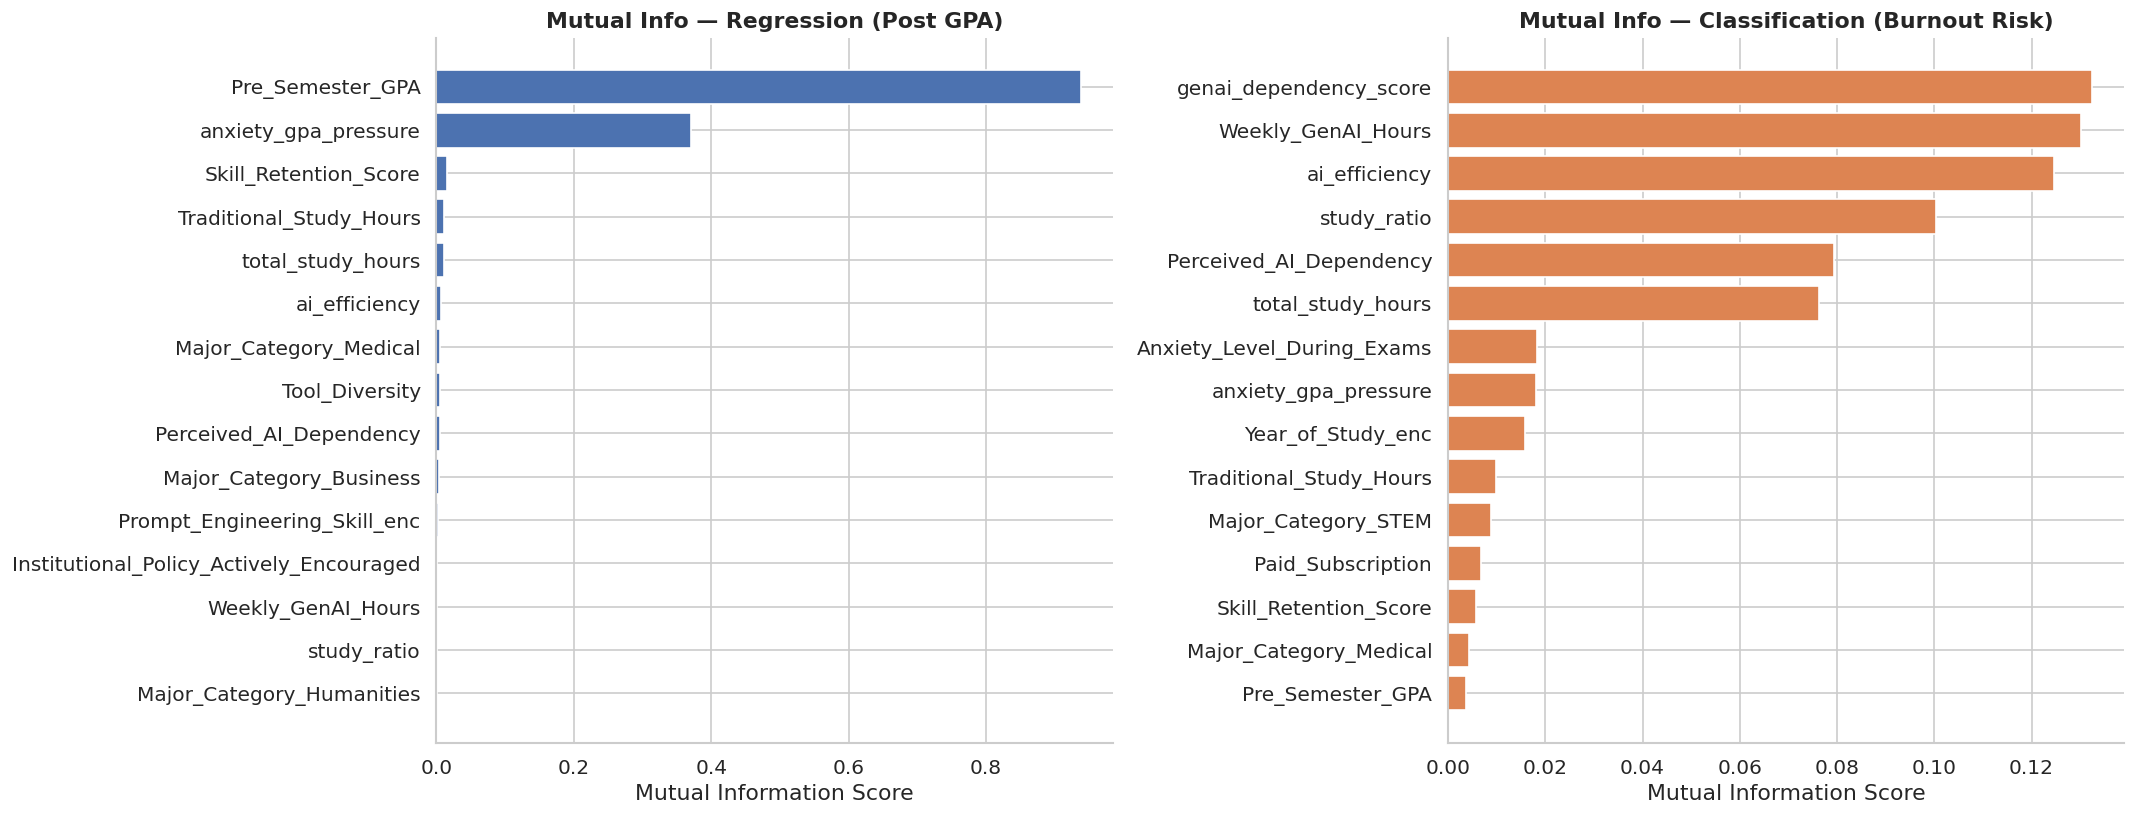

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Regression MI
top_reg = mi_reg_s.head(15)
axes[0].barh(top_reg.index[::-1], top_reg.values[::-1], color="#4C72B0", edgecolor="white")
axes[0].set_title("Mutual Info — Regression (Post GPA)", fontweight="bold")
axes[0].set_xlabel("Mutual Information Score")

# Classification MI
top_clf = mi_clf_s.head(15)
axes[1].barh(top_clf.index[::-1], top_clf.values[::-1], color="#DD8452", edgecolor="white")
axes[1].set_title("Mutual Info — Classification (Burnout Risk)", fontweight="bold")
axes[1].set_xlabel("Mutual Information Score")

plt.tight_layout()
save("13_mutual_information.png")

## 8. Build & Validate sklearn Pipeline
Build the production-ready preprocessor that will be used inside all model pipelines.

In [13]:
# After engineer_features() + ordinal encoding, all features are numeric
# The pipeline only needs: scaling for numerics, passthrough for binary/ordinals

# Separate by dtype for the pipeline
scale_cols   = [c for c in feature_cols if df_ohe[c].dtype in ["float64"]]
pass_cols    = [c for c in feature_cols if c not in scale_cols]

print(f"Columns to scale    ({len(scale_cols)}): {scale_cols}")
print(f"Columns to passthru ({len(pass_cols)}):  {pass_cols}")

Columns to scale    (9): ['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Traditional_Study_Hours', 'Skill_Retention_Score', 'study_ratio', 'total_study_hours', 'genai_dependency_score', 'ai_efficiency', 'anxiety_gpa_pressure']
Columns to passthru (15):  ['Tool_Diversity', 'Paid_Subscription', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams', 'Year_of_Study_enc', 'Prompt_Engineering_Skill_enc', 'Primary_Use_Case_enc', 'Major_Category_Arts', 'Major_Category_Business', 'Major_Category_Humanities', 'Major_Category_Medical', 'Major_Category_STEM', 'Institutional_Policy_Actively_Encouraged', 'Institutional_Policy_Allowed_With_Citation', 'Institutional_Policy_Strict_Ban']


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

scale_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

preprocessor = ColumnTransformer([
    ("scale", scale_pipeline, scale_cols),
    ("pass",  "passthrough",  pass_cols),
], remainder="drop")

# ── Quick validation on a small sample ──────────────────────────────────────
X_sample = df_ohe[feature_cols].head(500)
X_transformed = preprocessor.fit_transform(X_sample)
print(f"Input  shape: {X_sample.shape}")
print(f"Output shape: {X_transformed.shape}")
print(f"Any NaN in output: {np.isnan(X_transformed).any()}")
print("Pipeline validated ✓")

Input  shape: (500, 24)
Output shape: (500, 24)
Any NaN in output: False
Pipeline validated ✓


In [15]:
# Get output feature names
ohe_names = preprocessor.get_feature_names_out()
print(f"Total transformed features: {len(ohe_names)}")
print("Sample output feature names:", ohe_names[:10].tolist())

Total transformed features: 24
Sample output feature names: ['scale__Pre_Semester_GPA', 'scale__Weekly_GenAI_Hours', 'scale__Traditional_Study_Hours', 'scale__Skill_Retention_Score', 'scale__study_ratio', 'scale__total_study_hours', 'scale__genai_dependency_score', 'scale__ai_efficiency', 'scale__anxiety_gpa_pressure', 'pass__Tool_Diversity']


## 9. Train / Test Split & Save Processed Datasets

In [16]:
SEED = 42

X = df_ohe[feature_cols]
y_reg = df_ohe[TARGET_REG]
y_clf = df_ohe[TARGET_CLF]

# Stratify by burnout for classification; random for regression
X_train, X_test, yr_train, yr_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=SEED
)
_, _, yc_train, yc_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=SEED, stratify=y_clf
)

print(f"Train size : {len(X_train):,}  ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test size  : {len(X_test):,}   ({len(X_test)/len(X)*100:.0f}%)")
print()
print("Burnout class distribution in train (stratified):")
print(yc_train.value_counts(normalize=True).mul(100).round(1))
print()
print("Burnout class distribution in test (stratified):")
print(yc_test.value_counts(normalize=True).mul(100).round(1))

Train size : 40,000  (80%)
Test size  : 10,000   (20%)

Burnout class distribution in train (stratified):
Burnout_Risk_Level
Medium    42.3
Low       32.7
High      25.0
Name: proportion, dtype: float64

Burnout class distribution in test (stratified):
Burnout_Risk_Level
Medium    42.3
Low       32.7
High      25.0
Name: proportion, dtype: float64


In [17]:
# Save splits
X_train.to_parquet(PROCESSED / "X_train.parquet", index=False)
X_test.to_parquet (PROCESSED / "X_test.parquet",  index=False)
yr_train.to_frame().to_parquet(PROCESSED / "y_reg_train.parquet",  index=False)
yr_test.to_frame() .to_parquet(PROCESSED / "y_reg_test.parquet",   index=False)
yc_train.to_frame().to_parquet(PROCESSED / "y_clf_train.parquet",  index=False)
yc_test.to_frame() .to_parquet(PROCESSED / "y_clf_test.parquet",   index=False)

# Also save full engineered dataset (for reference)
df_ohe.to_parquet(PROCESSED / "features_full.parquet", index=False)

print("Saved to Data/processed/:")
for p in sorted(PROCESSED.glob("*.parquet")):
    size = p.stat().st_size / 1024
    print(f"  {p.name:<30} {size:.0f} KB")

Saved to Data/processed/:
  X_test.parquet                 469 KB
  X_train.parquet                1559 KB
  features_full.parquet          2000 KB
  y_clf_test.parquet             4 KB
  y_clf_train.parquet            11 KB
  y_reg_test.parquet             22 KB
  y_reg_train.parquet            69 KB


## 10. Correlation Matrix — After Engineering

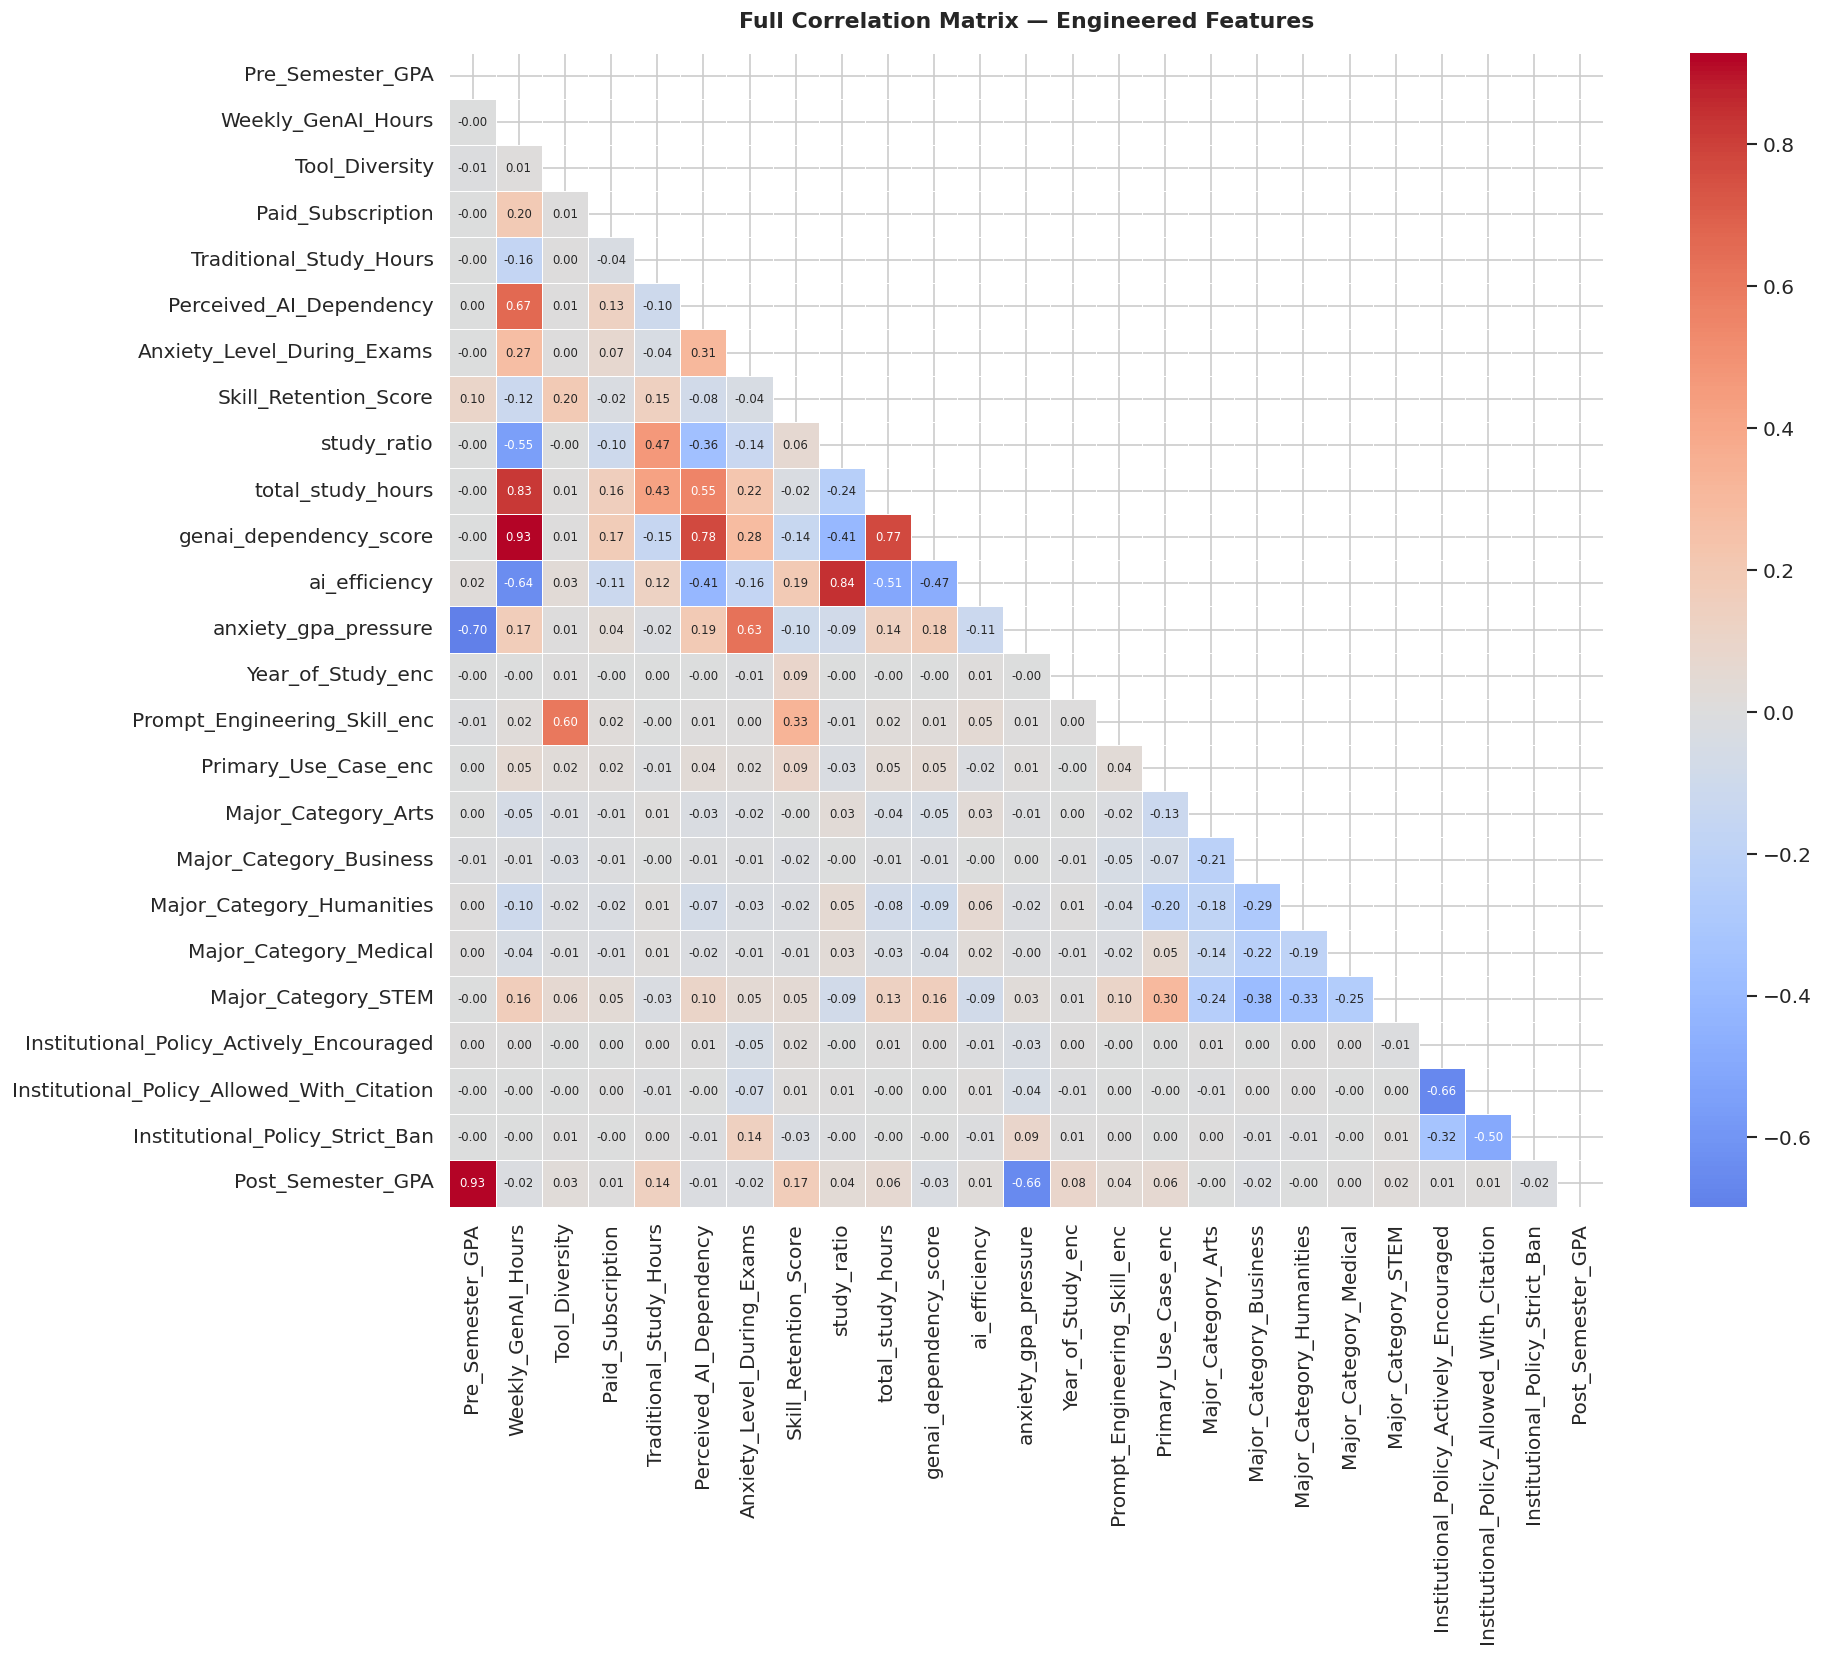

In [18]:
numeric_engineered = df_ohe[feature_cols + [TARGET_REG]].select_dtypes(include="number")
corr = numeric_engineered.corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    linewidths=0.4, linecolor="white",
    ax=ax, annot_kws={"size": 7},
    square=True
)
ax.set_title("Full Correlation Matrix — Engineered Features", fontweight="bold", pad=15)
plt.tight_layout()
save("14_engineered_correlation.png")

## 11. Feature Engineering Summary

| Feature | Type | Source | Rationale |
|---------|------|---------|-----------|
| `Pre_Semester_GPA` | Numerical | Raw | Strongest predictor (r=0.93) |
| `Weekly_GenAI_Hours` | Numerical | Raw | Core AI usage metric |
| `Traditional_Study_Hours` | Numerical | Raw | Positively correlates with GPA |
| `Perceived_AI_Dependency` | Numerical | Raw | Top burnout predictor |
| `Anxiety_Level_During_Exams` | Numerical | Raw | Student stress indicator |
| `Skill_Retention_Score` | Numerical | Raw | r=0.17 with GPA |
| `Tool_Diversity` | Numerical | Raw | Breadth of AI tool use |
| `study_ratio` | **Engineered** | Trad/GenAI | Captures substitution effect |
| `total_study_hours` | **Engineered** | Trad+GenAI | Overall cognitive load |
| `genai_dependency_score` | **Engineered** | GenAI×Dependency | Amplified risk signal for burnout |
| `ai_efficiency` | **Engineered** | Retention/GenAI | Quality of AI use per hour |
| `anxiety_gpa_pressure` | **Engineered** | Anxiety×(4−GPA) | Stress compound effect |
| `Year_of_Study_enc` | Ordinal | Year_of_Study | Ordered 1–5 (Freshman→Graduate) |
| `Prompt_Engineering_Skill_enc` | Ordinal | Prompt_Skill | Ordered 1–3 |
| `Primary_Use_Case_enc` | Ordinal | Primary_Use_Case | Ordered by avg GPA (passive→active) |
| `Major_Category_*` | OHE | Major_Category | No natural order |
| `Institutional_Policy_*` | OHE | Institutional_Policy | No natural order |
| `Paid_Subscription` | Binary | Raw | Already 0/1 |

**Total input features for models: ~26**

---
### Next Step → `03_modeling.ipynb`
